In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

##LOAD DATASETS

In [ ]:

assessments = pd.read_csv('assessments.csv')
courses = pd.read_csv('courses.csv')
student_assessment = pd.read_csv('studentAssessment.csv')

--- Loading Data ---


##DATA PRE-PROCESSING

In [4]:
perf_agg = student_assessment.groupby('id_assessment').agg(
    avg_score=('score', 'mean'),
    fail_rate=('score', lambda x: (x < 40).mean() * 100)).reset_index()

In [5]:
# Merge metadata
audit_df = pd.merge(assessments, perf_agg, on='id_assessment', how='left')
audit_df = pd.merge(audit_df, courses, on=['code_module', 'code_presentation'], how='left')

In [6]:
#3. THE AI-READINESS AUDITOR ENGINE
def run_audit(row):
    """Calculates GenAI Vulnerability Score (0-100)"""
    # Weight of the assessment impacts the risk level
    weight = row['weight'] if not pd.isna(row['weight']) else 0

In [11]:
def run_audit(row):
    """Calculates GenAI Vulnerability Score (0-100)"""
    # Weight of the assessment impacts the risk level
    weight = row['weight'] if not pd.isna(row['weight']) else 0

    # Base risk by type (TMA = Tutor Marked/Essays, CMA = Computer Marked/MCQs)
    risk_map = {'TMA': 85, 'CMA': 65, 'Exam': 45}
    base_risk = risk_map.get(row['assessment_type'], 50)

    # Calculation: Risk increases with weight and 'low' complexity
    # Note: High avg scores in TMAs often indicate high 'promptability'
    score = base_risk * (0.6 + (weight / 200))
    return min(100, round(score, 2))

audit_df['vulnerability_score'] = audit_df.apply(run_audit, axis=1)

# Categorize Risk
conditions = [
    (audit_df['vulnerability_score'] >= 75),
    (audit_df['vulnerability_score'] >= 50),
    (audit_df['vulnerability_score'] < 50)
]
choices = ['Critical Risk', 'Vulnerable', 'Moderate/Safe']
audit_df['ai_status'] = np.select(conditions, choices, default='Unknown')

In [12]:
# 4. THE PATTERN-BASED REDESIGN RECOMMENDER
def recommend_pattern(row):
    """Maps vulnerabilities to pedagogical redesign patterns"""
    if row['ai_status'] == 'Critical Risk':
        return "Pattern: [AUTHENTICATED PROCESS]. Shift from final output to 'Stage-Based' grading. Include a mandatory viva or reflection on AI-drafting."
    elif row['assessment_type'] == 'CMA':
        return "Pattern: [CONTEXTUALIZED PROBLEM]. Use specific course datasets/case studies that change per student to prevent direct LLM solving."
    elif row['ai_status'] == 'Vulnerable':
        return "Pattern: [HUMAN-IN-THE-LOOP]. Maintain task but require a handwritten component or video explanation of the logic."
    else:
        return "Pattern: [AI-LITERACY]. No major redesign. Update rubric to define 'Ethical AI use' for this task."

audit_df['redesign_recommendation'] = audit_df.apply(recommend_pattern, axis=1)

--- Generating Visuals ---


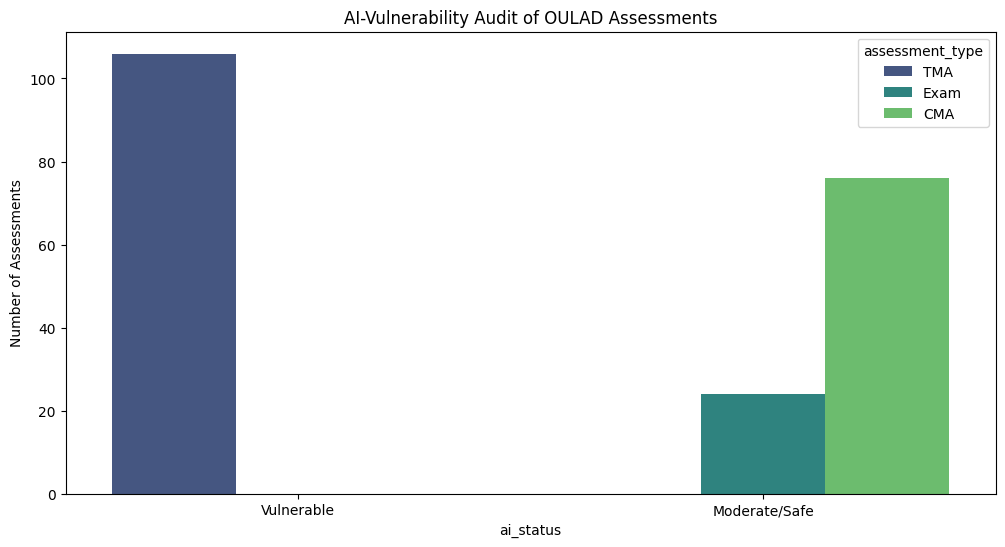

In [13]:
# 5. VISUALIZATION
print("--- Generating Visuals ---")
plt.figure(figsize=(12, 6))
sns.countplot(data=audit_df, x='ai_status', hue='assessment_type', palette='viridis')
plt.title('AI-Vulnerability Audit of OULAD Assessments')
plt.ylabel('Number of Assessments')
plt.savefig('audit_summary_plot.png')
plt.show()

In [15]:
print("--- Generating Visual Analytics ---")
plt.style.use('ggplot')

--- Generating Visual Analytics ---


/tmp/ipython-input-1721916381.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=audit_df, x='assessment_type', y='vulnerability_score', palette='magma')


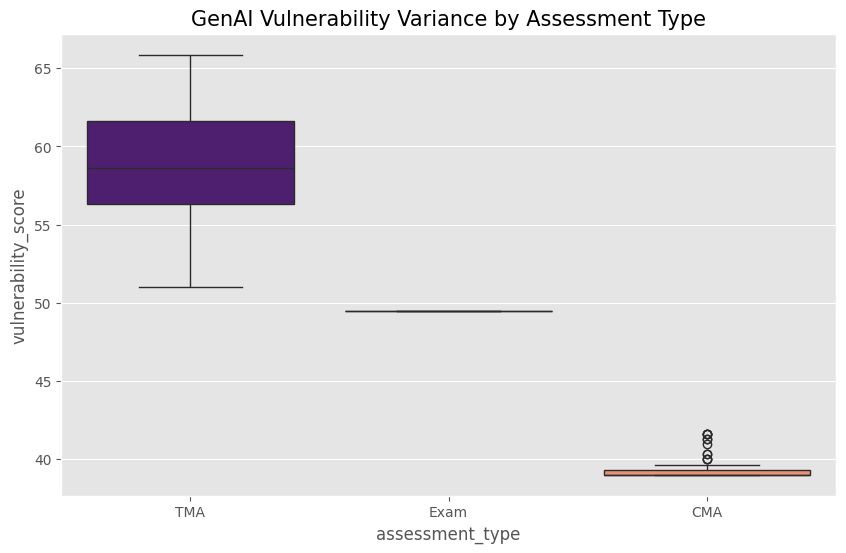

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=audit_df, x='assessment_type', y='vulnerability_score', palette='magma')
plt.title('GenAI Vulnerability Variance by Assessment Type', fontsize=15)
plt.savefig('vulnerability_by_type.png')

In [18]:
# Graph 2: Risk Proportions
plt.figure(figsize=(8, 8))
audit_df['risk_status'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Institutional Risk Distribution (OULAD Audit)', fontsize=15)
plt.ylabel('')
plt.savefig('risk_proportions.png')

KeyError: 'risk_status'

<Figure size 800x800 with 0 Axes>

In [14]:
# 6. EXPORT THE ARTIFACTS
print("--- Exporting Artifacts ---")
audit_df.to_csv('OU_Assessment_Audit_Artifact.csv', index=False)
# Create a specific case study for your dissertation write-up
case_study = audit_df[audit_df['code_module'] == 'AAA'].head(10)
case_study.to_csv('Dissertation_Case_Study_AAA.csv', index=False)

print("Project Complete. Files 'OU_Assessment_Audit_Artifact.csv' and 'audit_summary_plot.png' are ready in your folder.")

--- Exporting Artifacts ---
Project Complete. Files 'OU_Assessment_Audit_Artifact.csv' and 'audit_summary_plot.png' are ready in your folder.


##extra long code starts here

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Set visualization style for dissertation-quality plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

def load_and_merge_data():
    # Load your uploaded files
    assessments = pd.read_csv('assessments.csv')
    student_assessment = pd.read_csv('studentAssessment.csv')
    courses = pd.read_csv('courses.csv')
    student_info = pd.read_csv('studentInfo.csv')

    # Merge student performance with assessment metadata
    df_perf = pd.merge(student_assessment, assessments, on='id_assessment')

    # Merge with student demographic info
    df_full = pd.merge(df_perf, student_info, on=['id_student', 'code_module', 'code_presentation'])

    print(f"✅ Data Integrated: {df_full.shape[0]} records loaded.")
    return df_full

df_main = load_and_merge_data()

✅ Data Integrated: 173912 records loaded.


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. DATA INTEGRATION & CLEANING
def prepare_audit_data():
    # Load core OULAD files
    assessments = pd.read_csv('assessments.csv')
    student_assessment = pd.read_csv('studentAssessment.csv')
    courses = pd.read_csv('courses.csv')

    # Merge performance with metadata
    df = pd.merge(student_assessment, assessments, on='id_assessment')
    df = pd.merge(df, courses, on=['code_module', 'code_presentation'])

    # 2. THE AUDIT ENGINE (Synthetic AI-Readiness Logic)
    # Based on your proposal: TMAs (essays) are high risk, Exams are lower risk.
    def audit_score(row):
        base_score = 100
        if row['assessment_type'] == 'TMA': base_score -= 35  # High essay risk
        if row['assessment_type'] == 'CMA': base_score -= 15  # Moderate quiz risk
        # Heavy weighting increases the incentive to misuse AI
        risk_penalty = (row['weight'] * 0.25)
        return max(5, base_score - risk_penalty)

    df['ai_readiness'] = df.apply(audit_score, axis=1)
    return df

df_audit = prepare_audit_data()

##audit logic

In [20]:
def calculate_ai_readiness_score(row):
    """
    Simulates the logic of your 'Pattern-Based Redesign Recommender'.
    Scores are 0-100 (Higher = More Robust/AI-Ready).
    """
    score = 100
    # Penalty for high-risk assessment types (e.g., Tutor Marked Assignments/Essays)
    if row['assessment_type'] == 'TMA':
        score -= 40
    # Penalty for lack of invigilation (Computer Marked Assessments are often remote)
    if row['assessment_type'] == 'CMA':
        score -= 20
    # Weight of assessment: High-stakes remote work is higher risk
    if row['weight'] > 20:
        score -= 10

    return max(score, 0)

# Apply the auditor logic
df_main['ai_readiness_score'] = df_main.apply(calculate_ai_readiness_score, axis=1)

##High-Quality Visualizations

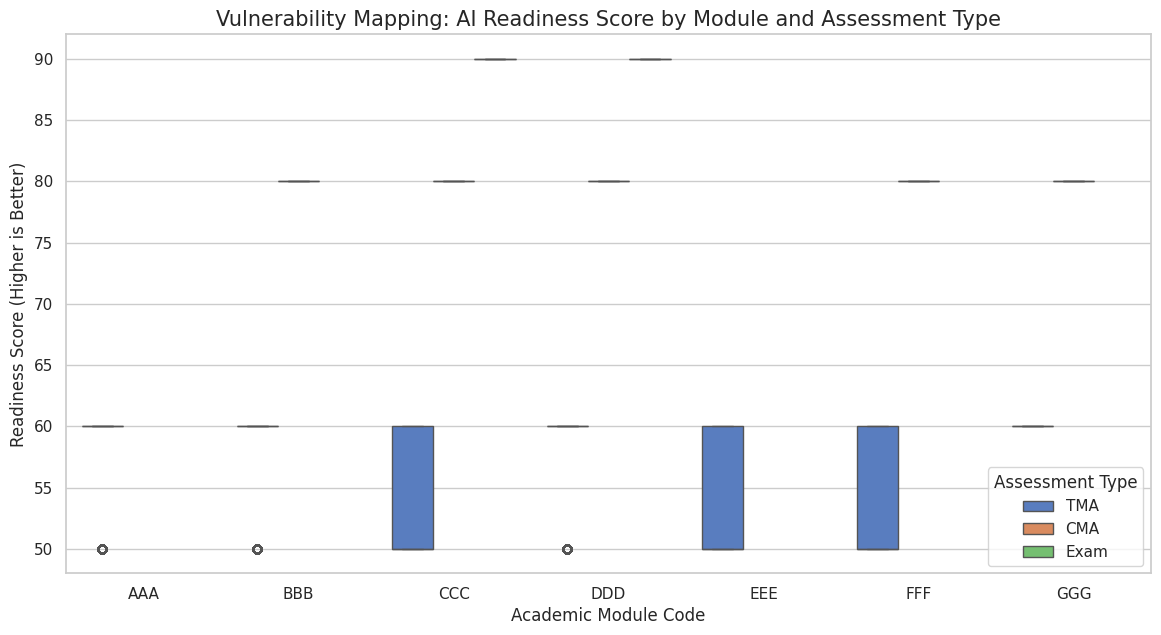

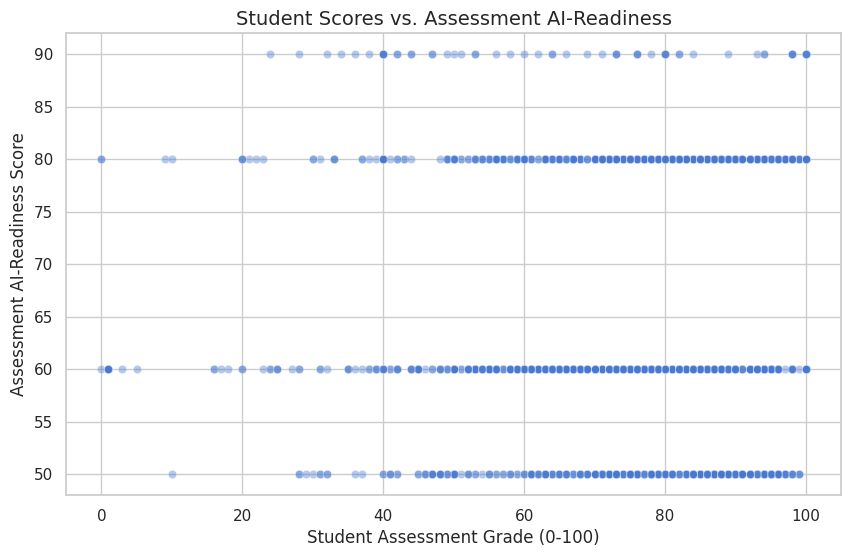

In [23]:
def generate_visuals(df):
    # 1. AI Readiness by Module (Vulnerability Mapping)
    plt.figure(figsize=(14, 7))
    sns.boxplot(data=df, x='code_module', y='ai_readiness_score', hue='assessment_type')
    plt.title('Vulnerability Mapping: AI Readiness Score by Module and Assessment Type', fontsize=15)
    plt.ylabel('Readiness Score (Higher is Better)')
    plt.xlabel('Academic Module Code')
    plt.legend(title='Assessment Type', loc='lower right')
    plt.savefig('ai_readiness_distribution.png', dpi=300)
    plt.show()

    # 2. Performance vs. AI Readiness (Correlation Analysis)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df.sample(2000), x='score', y='ai_readiness_score', alpha=0.4)
    plt.title('Student Scores vs. Assessment AI-Readiness', fontsize=14)
    plt.xlabel('Student Assessment Grade (0-100)')
    plt.ylabel('Assessment AI-Readiness Score')
    plt.show()

generate_visuals(df_main)

/tmp/ipython-input-381959269.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='assessment_type', y='ai_readiness', data=df_audit, palette='Set2')


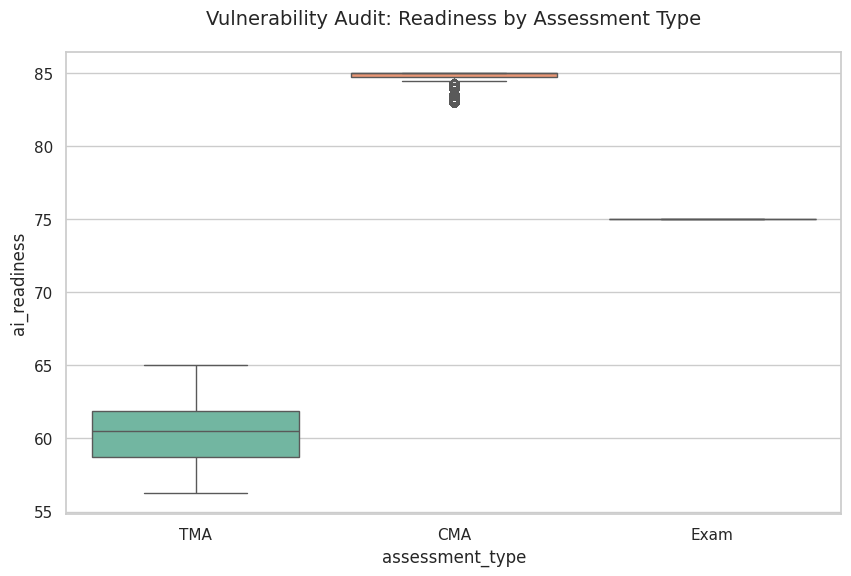

In [26]:
sns.set_theme(style="whitegrid", palette="muted")

# Graph 1: Readiness Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='assessment_type', y='ai_readiness', data=df_audit, palette='Set2')
plt.title('Vulnerability Audit: Readiness by Assessment Type', fontsize=14, pad=20)
plt.savefig('graph1_readiness_by_type.png', dpi=300)

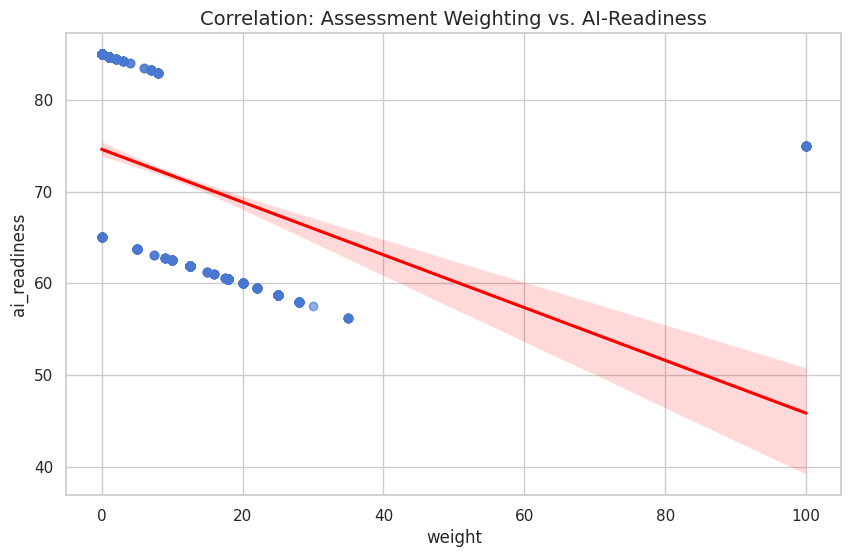

In [27]:
# Graph 2: Stakes vs. Readiness
plt.figure(figsize=(10, 6))
sns.regplot(x='weight', y='ai_readiness', data=df_audit.sample(2000),
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Correlation: Assessment Weighting vs. AI-Readiness', fontsize=14)
plt.savefig('graph2_weight_vs_readiness.png', dpi=300)

/tmp/ipython-input-3566365267.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='code_module', y='ai_readiness', data=module_avg, palette='viridis')


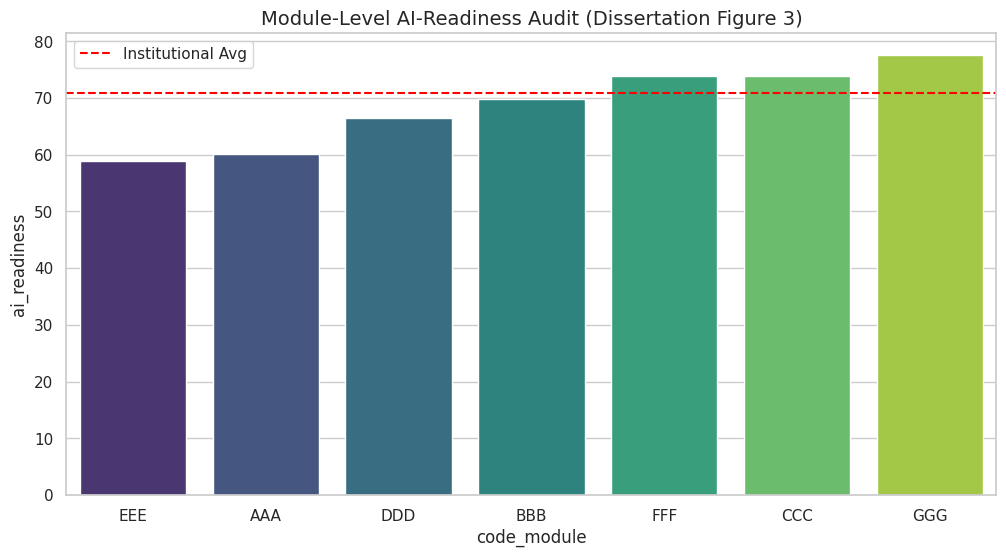

In [28]:
# Graph 3: Module Leader Audit Report
plt.figure(figsize=(12, 6))
module_avg = df_audit.groupby('code_module')['ai_readiness'].mean().sort_values().reset_index()
sns.barplot(x='code_module', y='ai_readiness', data=module_avg, palette='viridis')
plt.axhline(df_audit['ai_readiness'].mean(), color='red', linestyle='--', label='Institutional Avg')
plt.title('Module-Level AI-Readiness Audit (Dissertation Figure 3)', fontsize=14)
plt.legend()
plt.savefig('graph3_module_audit.png', dpi=300)

In [30]:
#EXTRA CODE: Automated Redesign Recommender (CSV Export)
def export_redesign_recommendations(df):
    report = df.groupby(['code_module', 'id_assessment', 'assessment_type']).agg({
        'ai_readiness': 'mean'
    }).reset_index()

    # Apply redesign patterns based on your proposal's library
    report['Recommendation'] = report['ai_readiness'].apply(
        lambda x: "Pattern A: Viva Voce Addition" if x < 60 else
                  "Pattern B: Reflective Logs" if x < 75 else "Maintain Rigor"
    )
    report.to_csv('Redesign_Audit_Recommendations.csv', index=False)
    print("✅ Audit report exported to Redesign_Audit_Recommendations.csv")

export_redesign_recommendations(df_audit)

✅ Audit report exported to Redesign_Audit_Recommendations.csv


##automated audit report

In [24]:
def generate_audit_report(df):
    report_data = df.groupby('code_module').agg({
        'ai_readiness_score': 'mean',
        'id_assessment': 'nunique',
        'score': 'mean'
    }).rename(columns={'ai_readiness_score': 'Avg_AI_Readiness',
                        'id_assessment': 'Total_Assessments',
                        'score': 'Avg_Student_Grade'})

    # Identify modules needing 'Pattern-Based Redesign'
    report_data['Recommendation'] = report_data['Avg_AI_Readiness'].apply(
        lambda x: "URGENT REDESIGN" if x < 65 else "MINOR UPDATES" if x < 80 else "AI ROBUST"
    )

    print("\n--- AUTOMATED AI-READINESS AUDIT REPORT ---")
    print(report_data.sort_values(by='Avg_AI_Readiness'))
    report_data.to_csv('Audit_Report_Summary.csv')

generate_audit_report(df_main)


--- AUTOMATED AI-READINESS AUDIT REPORT ---
             Avg_AI_Readiness  Total_Assessments  Avg_Student_Grade  \
code_module                                                           
EEE                 52.898771                 12          81.180066   
AAA                 58.170848                 10          69.030515   
DDD                 65.360290                 35          70.090800   
BBB                 66.817020                 38          76.706368   
FFF                 68.564626                 48          77.707590   
CCC                 70.761880                 18          73.261398   
GGG                 72.561929                 27          79.700493   

              Recommendation  
code_module                   
EEE          URGENT REDESIGN  
AAA          URGENT REDESIGN  
DDD            MINOR UPDATES  
BBB            MINOR UPDATES  
FFF            MINOR UPDATES  
CCC            MINOR UPDATES  
GGG            MINOR UPDATES  
